In [1]:
from os.path import join
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from brainiak.isc import squareform_isfc
from statistical_tests import bootstrap_test
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import PredefinedSplit
from sklearn.metrics import balanced_accuracy_score
from ctf_dataset.load import create_wrapped_dataset

In [2]:
base_dir = '/jukebox/hasson/snastase/social-ctf'
data_dir = join(base_dir, 'data_v1')
wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual_v2.hdf5")

sns.set(context='notebook', style='white')
palette = sns.color_palette(['.65', 'darkgoldenrod'])

In [3]:
# Load in scores and wins
matchup_id = 0

scores = np.load(f'results/scores_matchup-{matchup_id}.npy').astype('float64')
wins = np.load(f'results/wins_matchup-{matchup_id}.npy').astype('float64')
wins_draw = -(1 - 2 * wins) * np.expand_dims(np.sum(wins, axis=-1), 2)

In [4]:
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

n_pairs = n_players * (n_players - 1) // 2
coop_ids = (0, 5)

In [5]:
# Load in all ISCs
matchup_id = 0

iscs = np.load(f'results/iscs_matchup-{matchup_id}_data-v1.npy')
print(iscs.shape)

(32, 32, 6, 142)


In [6]:
# Stack ISCs, wins, and map IDs for modeling
iscs_stack, wins_stack, map_ids = [], [], []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        iscs_stack.append(iscs[map_id, repeat_id, coop_ids])   
        wins_stack.extend(wins[map_id, repeat_id])
        map_ids.extend([map_id, map_id])
iscs_stack = np.vstack(iscs_stack)
wins_stack = np.array(wins_stack)
map_ids = np.array(map_ids)
assert map_ids.shape[0] == wins_stack.shape[0] == iscs_stack.shape[0]

In [7]:
# Classify wins based on ISC
clf = LogisticRegression(penalty='none', max_iter=300,
                         class_weight='balanced')

# Set up leave-one-map-out cross-validation
cv = PredefinedSplit(map_ids)

scores, weights = [], []
for f, (train, test) in enumerate(cv.split()):

    # Z-score training SPIs and test SPIs (based on training set)
    scaler = StandardScaler()
    iscs_train = scaler.fit_transform(iscs_stack[train])
    iscs_test = scaler.transform(iscs_stack[test])

    # Train competitive/cooperative classifier based on train SPIs
    clf.fit(iscs_train, wins_stack[train])
    weights.append(clf.coef_)

    # Use fitted classifier to predict test cooperative/competitive 
    pred = clf.predict(iscs_test)

    # Evaluate classifier accuracy
    score = balanced_accuracy_score(wins_stack[test], pred)
    scores.append(score)
    print(f"Fold {f} accuracy: {score:.3f}")

print(f'Mean accuracy: {np.mean(scores):.3f}\n')    

Fold 0 accuracy: 0.748
Fold 1 accuracy: 0.725
Fold 2 accuracy: 0.679
Fold 3 accuracy: 0.708
Fold 4 accuracy: 0.708
Fold 5 accuracy: 0.685
Fold 6 accuracy: 0.766
Fold 7 accuracy: 0.669
Fold 8 accuracy: 0.830
Fold 9 accuracy: 0.617
Fold 10 accuracy: 0.728
Fold 11 accuracy: 0.777
Fold 12 accuracy: 0.776
Fold 13 accuracy: 0.629
Fold 14 accuracy: 0.621
Fold 15 accuracy: 0.742
Fold 16 accuracy: 0.756
Fold 17 accuracy: 0.730
Fold 18 accuracy: 0.642
Fold 19 accuracy: 0.687
Fold 20 accuracy: 0.702
Fold 21 accuracy: 0.756
Fold 22 accuracy: 0.794
Fold 23 accuracy: 0.780
Fold 24 accuracy: 0.668
Fold 25 accuracy: 0.675
Fold 26 accuracy: 0.687
Fold 27 accuracy: 0.679
Fold 28 accuracy: 0.725
Fold 29 accuracy: 0.550
Fold 30 accuracy: 0.663
Fold 31 accuracy: 0.752
Mean accuracy: 0.708



In [8]:
# Bootstrap 95% confidence intervals around accuracy
mean, ci, p, _ = bootstrap_test(np.array(scores), bootstrap_axis=0,
                                n_bootstraps=10000, estimator=np.mean,
                                null_estimate=.50)
print(f'mean score: {mean:.3f}')
print(f'95% CI: {[f"{c:.3f}" for c in ci]}')
print(f'p-value: {p}')

mean score: 0.708
95% CI: ['0.687', '0.728']
p-value: 9.999000099990002e-05


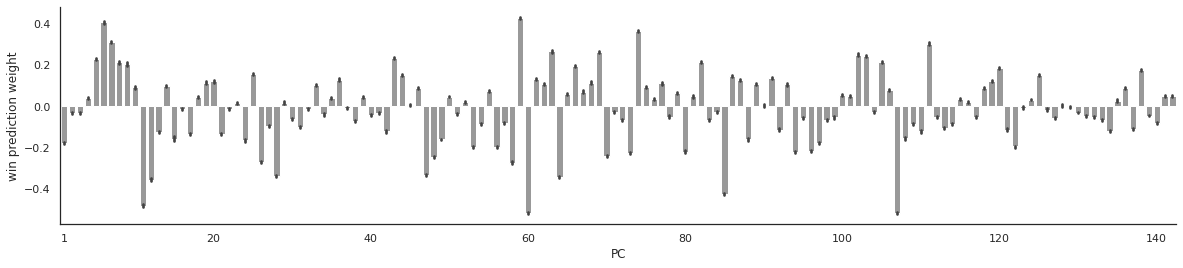

In [71]:
weights = np.vstack(weights)
weights_df = {'weight': [], 'PC': [], 'map': []}
for map_id in np.arange(n_maps):
    for pc_id in np.arange(n_pcs):
        weights_df['weight'].append(weights[map_id, pc_id])
        weights_df['PC'].append(pc_id)
        weights_df['map'].append(map_id)
        
fig, ax = plt.subplots(figsize=(20, 4));
sns.barplot(x='PC', y='weight', data=weights_df, color='.6', ax=ax)
ax.set(xlabel='PC', ylabel='win prediction weight')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
sns.despine()

In [9]:
# Load in all ISCs
matchup_id = 0

iscs = np.load(f'results/iscs_reg-pre_matchup-{matchup_id}_data-v1.npy')
print(iscs.shape)

(32, 32, 6, 142)


In [10]:
# Stack ISCs, wins, and map IDs for modeling
iscs_stack, wins_stack, map_ids = [], [], []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        iscs_stack.append(iscs[map_id, repeat_id, coop_ids])   
        wins_stack.extend(wins[map_id, repeat_id])
        map_ids.extend([map_id, map_id])
iscs_stack = np.vstack(iscs_stack)
wins_stack = np.array(wins_stack)
map_ids = np.array(map_ids)
assert map_ids.shape[0] == wins_stack.shape[0] == iscs_stack.shape[0]

In [11]:
# Classify wins based on ISC
clf = LogisticRegression(penalty='none', max_iter=300,
                         class_weight='balanced')

# Set up leave-one-map-out cross-validation
cv = PredefinedSplit(map_ids)

scores, weights = [], []
for f, (train, test) in enumerate(cv.split()):

    # Z-score training SPIs and test SPIs (based on training set)
    scaler = StandardScaler()
    iscs_train = scaler.fit_transform(iscs_stack[train])
    iscs_test = scaler.transform(iscs_stack[test])

    # Train competitive/cooperative classifier based on train SPIs
    clf.fit(iscs_train, wins_stack[train])
    weights.append(clf.coef_)

    # Use fitted classifier to predict test cooperative/competitive 
    pred = clf.predict(iscs_test)

    # Evaluate classifier accuracy
    score = balanced_accuracy_score(wins_stack[test], pred)
    scores.append(score)
    print(f"Fold {f} accuracy: {score:.3f}")

print(f'Mean accuracy: {np.mean(scores):.3f}\n')    

Fold 0 accuracy: 0.749
Fold 1 accuracy: 0.533
Fold 2 accuracy: 0.635
Fold 3 accuracy: 0.565
Fold 4 accuracy: 0.657
Fold 5 accuracy: 0.619
Fold 6 accuracy: 0.632
Fold 7 accuracy: 0.728
Fold 8 accuracy: 0.674
Fold 9 accuracy: 0.560
Fold 10 accuracy: 0.736
Fold 11 accuracy: 0.568
Fold 12 accuracy: 0.690
Fold 13 accuracy: 0.558
Fold 14 accuracy: 0.613
Fold 15 accuracy: 0.669
Fold 16 accuracy: 0.535
Fold 17 accuracy: 0.501
Fold 18 accuracy: 0.500
Fold 19 accuracy: 0.659
Fold 20 accuracy: 0.619
Fold 21 accuracy: 0.631
Fold 22 accuracy: 0.601
Fold 23 accuracy: 0.668
Fold 24 accuracy: 0.528
Fold 25 accuracy: 0.635
Fold 26 accuracy: 0.571
Fold 27 accuracy: 0.613
Fold 28 accuracy: 0.636
Fold 29 accuracy: 0.610
Fold 30 accuracy: 0.643
Fold 31 accuracy: 0.735
Mean accuracy: 0.621



In [12]:
# Bootstrap 95% confidence intervals around accuracy
mean, ci, p, _ = bootstrap_test(np.array(scores), bootstrap_axis=0,
                                n_bootstraps=10000, estimator=np.mean,
                                null_estimate=.50)
print(f'mean score: {mean:.3f}')
print(f'95% CI: {[f"{c:.3f}" for c in ci]}')
print(f'p-value: {p}')

mean score: 0.621
95% CI: ['0.599', '0.644']
p-value: 9.999000099990002e-05


In [99]:
# Load in all ISFCs
matchup_id = 0

isfcs = np.load(f'results/isfcs_matchup-{matchup_id}_data-v1.npy')
print(isfcs.shape)

(32, 32, 6, 142, 142)


In [100]:
# Stack ISFCs, wins, and map IDs for modeling
isfcs_stack = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        isfcs_stack.append(np.concatenate(
            squareform_isfc(isfcs[map_id, repeat_id, coop_ids[0]])))
        isfcs_stack.append(np.concatenate(
            squareform_isfc(isfcs[map_id, repeat_id, coop_ids[1]])))  
isfcs_stack = np.vstack(isfcs_stack)
assert map_ids.shape[0] == wins_stack.shape[0] == isfcs_stack.shape[0]

In [ ]:
# Classify wins bassed on ISFC
# Set up leave-one-map-out cross-validation
cv = PredefinedSplit(map_ids)

scores = []
for f, (train, test) in enumerate(cv.split()):

    # Z-score training SPIs and test SPIs (based on training set)
    scaler = StandardScaler()
    isfcs_train = scaler.fit_transform(isfcs_stack[train])
    isfcs_test = scaler.transform(isfcs_stack[test])

    inner_cv = PredefinedSplit(map_ids[train])
    clf = LogisticRegressionCV(Cs=10, cv=inner_cv, max_iter=500,
                               class_weight='balanced')
    
    # Train competitive/cooperative classifier based on train SPIs
    clf.fit(isfcs_train, wins_stack[train])

    # Use fitted classifier to predict test cooperative/competitive 
    pred = clf.predict(isfcs_test)

    # Evaluate classifier accuracy
    score = balanced_accuracy_score(wins_stack[test], pred)
    scores.append(score)
    print(f"Fold {f} accuracy: {score:.3f}")

np.save('results/win-classification_isfcs.npy', np.array(scores))
print(f'Mean accuracy: {np.mean(scores):.3f}\n')

Fold 0 accuracy: 0.985
Fold 1 accuracy: 0.986
Fold 2 accuracy: 0.895
Fold 3 accuracy: 0.968
Fold 4 accuracy: 0.968
Fold 5 accuracy: 0.972
Fold 6 accuracy: 0.969
Fold 7 accuracy: 0.954
Fold 8 accuracy: 1.000
Fold 9 accuracy: 0.972
Fold 10 accuracy: 0.983
Fold 11 accuracy: 0.932
Fold 12 accuracy: 0.944
Fold 13 accuracy: 0.972
Fold 14 accuracy: 0.937
Fold 15 accuracy: 0.923


In [140]:
# Load back in ISFC scores
scores = np.load('results/win-classification_isfcs.npy')
np.mean(scores)

0.9532658643222693

In [141]:
# Bootstrap 95% confidence intervals around accuracy
mean, ci, p, _ = bootstrap_test(np.array(scores), bootstrap_axis=0,
                                n_bootstraps=10000, estimator=np.mean)
print(f'mean score: {mean:.3f}')
print(f'95% CI: {[f"{c:.3f}" for c in ci]}')
print(f'p-value: {p}')

mean score: 0.953
95% CI: ['0.940', '0.964']
p-value: 9.999000099990002e-05


In [94]:
# Load in all ISFCs
matchup_id = 0

isfcs = np.load(f'results/isfcs_reg-pre_matchup-{matchup_id}_data-v1.npy')
print(isfcs.shape)

(32, 32, 6, 142, 142)


In [95]:
# Stack ISFCs, wins, and map IDs for modeling
isfcs_stack = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        isfcs_stack.append(np.concatenate(
            squareform_isfc(isfcs[map_id, repeat_id, coop_ids[0]])))
        isfcs_stack.append(np.concatenate(
            squareform_isfc(isfcs[map_id, repeat_id, coop_ids[1]])))  
isfcs_stack = np.vstack(isfcs_stack)
assert map_ids.shape[0] == wins_stack.shape[0] == isfcs_stack.shape[0]

In [ ]:
# Classify wins bassed on ISFC
# Set up leave-one-map-out cross-validation
cv = PredefinedSplit(map_ids)

scores = []
for f, (train, test) in enumerate(cv.split()):

    # Z-score training SPIs and test SPIs (based on training set)
    scaler = StandardScaler()
    isfcs_train = scaler.fit_transform(isfcs_stack[train])
    isfcs_test = scaler.transform(isfcs_stack[test])

    inner_cv = PredefinedSplit(map_ids[train])
    clf = LogisticRegressionCV(Cs=10, cv=inner_cv, max_iter=500,
                               class_weight='balanced')
    
    # Train competitive/cooperative classifier based on train SPIs
    clf.fit(isfcs_train, wins_stack[train])

    # Use fitted classifier to predict test cooperative/competitive 
    pred = clf.predict(isfcs_test)

    # Evaluate classifier accuracy
    score = balanced_accuracy_score(wins_stack[test], pred)
    scores.append(score)
    print(f"Fold {f} accuracy: {score:.3f}")

np.save('results/win-classification_isfcs_reg-pre.npy', np.array(scores))
print(f'Mean accuracy: {np.mean(scores):.3f}\n')

Fold 0 accuracy: 0.858
Fold 1 accuracy: 0.789
Fold 2 accuracy: 0.791
Fold 3 accuracy: 0.776
Fold 4 accuracy: 0.790
Fold 5 accuracy: 0.849
Fold 6 accuracy: 0.847
Fold 7 accuracy: 0.796
Fold 8 accuracy: 0.893
Fold 9 accuracy: 0.653
Fold 10 accuracy: 0.854
Fold 11 accuracy: 0.726
Fold 12 accuracy: 0.792
Fold 13 accuracy: 0.736
Fold 16 accuracy: 0.762


In [142]:
# Load back in ISFC scores
scores = np.load('results/win-classification_isfcs_reg-pre.npy')
np.mean(scores)

0.7847576499285975

In [143]:
# Bootstrap 95% confidence intervals around accuracy
mean, ci, p, _ = bootstrap_test(np.array(scores), bootstrap_axis=0,
                                n_bootstraps=10000, estimator=np.mean)
print(f'mean score: {mean:.3f}')
print(f'95% CI: {[f"{c:.3f}" for c in ci]}')
print(f'p-value: {p}')

mean score: 0.785
95% CI: ['0.764', '0.805']
p-value: 9.999000099990002e-05


In [147]:
# Reload ISCs
iscs = np.load(f'results/iscs_matchup-{matchup_id}_data-v1.npy')

# Load in scores and compute differences
game_scores = np.load(f'results/scores_matchup-{matchup_id}.npy').astype('float64')

# Stack ISCs, wins, and map IDs for modeling
iscs_stack, scores_stack, map_ids = [], [], []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        iscs_stack.append((iscs[map_id, repeat_id, coop_ids[0]] - 
                           iscs[map_id, repeat_id, coop_ids[1]]))  
        scores_stack.append((game_scores[map_id, repeat_id, 0] - 
                             game_scores[map_id, repeat_id, 1]))
        map_ids.append(map_id)
iscs_stack = np.vstack(iscs_stack)
scores_stack = np.array(scores_stack)
map_ids = np.array(map_ids)
assert map_ids.shape[0] == scores_stack.shape[0] == iscs_stack.shape[0]

In [148]:
# Initialize simple classifier
reg = LinearRegression()

# Set up leave-one-map-out cross-validation
cv = PredefinedSplit(map_ids)

reg_scores, preds = [], []
for f, (train, test) in enumerate(cv.split()):

    # Z-score training SPIs and test SPIs (based on training set)
    scaler = StandardScaler()
    iscs_train = scaler.fit_transform(iscs_stack[train])
    iscs_test = scaler.transform(iscs_stack[test])

    # Train competitive/cooperative classifier based on train SPIs
    reg.fit(iscs_train, scores_stack[train])

    # Use fitted classifier to predict test cooperative/competitive 
    pred = reg.predict(iscs_test)
    preds.append(pred)

    # Evaluate classifier accuracy
    reg_score = pearsonr(scores_stack[test], pred)[0]
    reg_scores.append(reg_score)
    print(f"Fold {f} correlation: {reg_score:.3f}")

print(f'Mean correlation: {np.mean(reg_scores):.3f}\n')  

Fold 0 correlation: 0.755
Fold 1 correlation: 0.801
Fold 2 correlation: 0.701
Fold 3 correlation: 0.702
Fold 4 correlation: 0.665
Fold 5 correlation: 0.689
Fold 6 correlation: 0.826
Fold 7 correlation: 0.687
Fold 8 correlation: 0.832
Fold 9 correlation: 0.680
Fold 10 correlation: 0.755
Fold 11 correlation: 0.628
Fold 12 correlation: 0.717
Fold 13 correlation: 0.590
Fold 14 correlation: 0.522
Fold 15 correlation: 0.776
Fold 16 correlation: 0.802
Fold 17 correlation: 0.666
Fold 18 correlation: 0.668
Fold 19 correlation: 0.699
Fold 20 correlation: 0.826
Fold 21 correlation: 0.712
Fold 22 correlation: 0.857
Fold 23 correlation: 0.684
Fold 24 correlation: 0.707
Fold 25 correlation: 0.529
Fold 26 correlation: 0.832
Fold 27 correlation: 0.597
Fold 28 correlation: 0.699
Fold 29 correlation: 0.706
Fold 30 correlation: 0.904
Fold 31 correlation: 0.729
Mean correlation: 0.717



In [149]:
# Bootstrap 95% confidence intervals around accuracy
mean, ci, p, _ = bootstrap_test(np.array(reg_scores), bootstrap_axis=0,
                                n_bootstraps=10000, estimator=np.mean)
print(f'mean score: {mean:.3f}')
print(f'95% CI: {[f"{c:.3f}" for c in ci]}')
print(f'p-value: {p}')

mean score: 0.717
95% CI: ['0.687', '0.748']
p-value: 9.999000099990002e-05


(0.7185365736201663, 2.2962860636063885e-163)


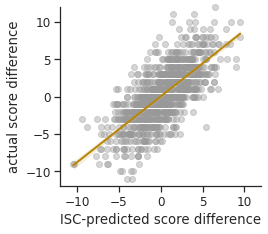

In [112]:
print(pearsonr(np.concatenate(preds), scores_stack))
scores_df = pd.DataFrame({'predicted': np.concatenate(preds),
                          'actual': scores_stack})
sns.set(style='ticks', font_scale=1.1)
fig, ax = plt.subplots(figsize=(3.6, 3.3))
sns.regplot(x='predicted', y='actual', data=scores_df,
            ax=ax, color='.6',
            scatter_kws=dict(clip_on=False, alpha=.4),
            line_kws=dict(color='darkgoldenrod', lw=2))
ax.set(ylabel='actual score difference',
       xlabel='ISC-predicted score difference',
       xlim=(-12, 12), ylim=(-12, 12))
sns.despine()
plt.savefig(f'figures/clf-score_scatter_matchup-{matchup_id}.svg',
            dpi=300, bbox_inches='tight', transparent=True)

(0.08101111573782807, 0.009501751744786666)


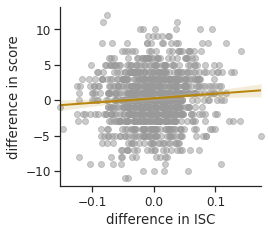

In [103]:
pc_id = 4
iscs_diff = np.concatenate(iscs[..., 0, pc_id] -
                           iscs[..., 5, pc_id])
print(pearsonr(iscs_diff, scores_stack))

scores_df = pd.DataFrame({'predicted': iscs_diff,
                          'actual': scores_stack})
sns.set(style='ticks', font_scale=1.1)
fig, ax = plt.subplots(figsize=(3.6, 3.3))
sns.regplot(x='predicted', y='actual', data=scores_df,
            ax=ax, color='.6',
            scatter_kws=dict(clip_on=False, alpha=.5),
            line_kws=dict(color='darkgoldenrod', lw=2))
ax.set(ylabel='difference in score',
       xlabel='difference in ISC')
sns.despine()

In [150]:
# Reload ISCs
iscs = np.load(f'results/iscs_reg-pre_matchup-{matchup_id}_data-v1.npy')

# Load in scores and compute differences
game_scores = np.load(f'results/scores_matchup-{matchup_id}.npy').astype('float64')

# Stack ISCs, wins, and map IDs for modeling
iscs_stack, scores_stack, map_ids = [], [], []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        iscs_stack.append((iscs[map_id, repeat_id, coop_ids[0]] - 
                           iscs[map_id, repeat_id, coop_ids[1]]))  
        scores_stack.append((game_scores[map_id, repeat_id, 0] - 
                             game_scores[map_id, repeat_id, 1]))
        map_ids.append(map_id)
iscs_stack = np.vstack(iscs_stack)
scores_stack = np.array(scores_stack)
map_ids = np.array(map_ids)
assert map_ids.shape[0] == scores_stack.shape[0] == iscs_stack.shape[0]

In [151]:
# Initialize simple classifier
reg = LinearRegression()

# Set up leave-one-map-out cross-validation
cv = PredefinedSplit(map_ids)

reg_scores, preds = [], []
for f, (train, test) in enumerate(cv.split()):

    # Z-score training SPIs and test SPIs (based on training set)
    scaler = StandardScaler()
    iscs_train = scaler.fit_transform(iscs_stack[train])
    iscs_test = scaler.transform(iscs_stack[test])

    # Train competitive/cooperative classifier based on train SPIs
    reg.fit(iscs_train, scores_stack[train])

    # Use fitted classifier to predict test cooperative/competitive 
    pred = reg.predict(iscs_test)
    preds.append(pred)

    # Evaluate classifier accuracy
    reg_score = pearsonr(scores_stack[test], pred)[0]
    reg_scores.append(reg_score)
    print(f"Fold {f} correlation: {reg_score:.3f}")

print(f'Mean correlation: {np.mean(reg_scores):.3f}\n')  

Fold 0 correlation: 0.734
Fold 1 correlation: 0.350
Fold 2 correlation: 0.503
Fold 3 correlation: 0.408
Fold 4 correlation: 0.532
Fold 5 correlation: 0.564
Fold 6 correlation: 0.325
Fold 7 correlation: 0.466
Fold 8 correlation: 0.578
Fold 9 correlation: 0.630
Fold 10 correlation: 0.591
Fold 11 correlation: 0.496
Fold 12 correlation: 0.302
Fold 13 correlation: 0.440
Fold 14 correlation: 0.370
Fold 15 correlation: 0.639
Fold 16 correlation: 0.318
Fold 17 correlation: 0.550
Fold 18 correlation: 0.226
Fold 19 correlation: 0.396
Fold 20 correlation: 0.295
Fold 21 correlation: 0.454
Fold 22 correlation: 0.633
Fold 23 correlation: 0.668
Fold 24 correlation: 0.543
Fold 25 correlation: 0.552
Fold 26 correlation: 0.266
Fold 27 correlation: 0.539
Fold 28 correlation: 0.543
Fold 29 correlation: 0.623
Fold 30 correlation: 0.557
Fold 31 correlation: 0.590
Mean correlation: 0.490



In [152]:
# Bootstrap 95% confidence intervals around accuracy
mean, ci, p, _ = bootstrap_test(np.array(reg_scores), bootstrap_axis=0,
                                n_bootstraps=10000, estimator=np.mean)
print(f'mean score: {mean:.3f}')
print(f'95% CI: {[f"{c:.3f}" for c in ci]}')
print(f'p-value: {p}')

mean score: 0.490
95% CI: ['0.445', '0.534']
p-value: 9.999000099990002e-05


In [158]:
# Try win classification with mismatching teammates!
iscs_stack, wins_stack, map_ids = [], [], []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        #iscs_stack.append(iscs[map_id, repeat_id, coop_ids])   
        iscs_stack.append(iscs[map_id, repeat_id, [1, 4]]) 
        wins_stack.extend(wins[map_id, repeat_id])
        map_ids.extend([map_id, map_id])
iscs_stack = np.vstack(iscs_stack)
wins_stack = np.array(wins_stack)
map_ids = np.array(map_ids)
assert map_ids.shape[0] == wins_stack.shape[0] == iscs_stack.shape[0]

In [159]:
# Classify wins based on ISC
clf = LogisticRegression(penalty='none', max_iter=300,
                         class_weight='balanced')

# Set up leave-one-map-out cross-validation
cv = PredefinedSplit(map_ids)

scores, weights = [], []
for f, (train, test) in enumerate(cv.split()):

    # Z-score training SPIs and test SPIs (based on training set)
    scaler = StandardScaler()
    iscs_train = scaler.fit_transform(iscs_stack[train])
    iscs_test = scaler.transform(iscs_stack[test])

    # Train competitive/cooperative classifier based on train SPIs
    clf.fit(iscs_train, wins_stack[train])
    weights.append(clf.coef_)

    # Use fitted classifier to predict test cooperative/competitive 
    pred = clf.predict(iscs_test)

    # Evaluate classifier accuracy
    score = balanced_accuracy_score(wins_stack[test], pred)
    scores.append(score)
    print(f"Fold {f} accuracy: {score:.3f}")

print(f'Mean accuracy: {np.mean(scores):.3f}\n')    

Fold 0 accuracy: 0.513
Fold 1 accuracy: 0.506
Fold 2 accuracy: 0.538
Fold 3 accuracy: 0.375
Fold 4 accuracy: 0.488
Fold 5 accuracy: 0.546
Fold 6 accuracy: 0.500
Fold 7 accuracy: 0.558
Fold 8 accuracy: 0.472
Fold 9 accuracy: 0.538
Fold 10 accuracy: 0.479
Fold 11 accuracy: 0.472
Fold 12 accuracy: 0.502
Fold 13 accuracy: 0.556
Fold 14 accuracy: 0.442
Fold 15 accuracy: 0.440
Fold 16 accuracy: 0.489
Fold 17 accuracy: 0.441
Fold 18 accuracy: 0.588
Fold 19 accuracy: 0.536
Fold 20 accuracy: 0.548
Fold 21 accuracy: 0.472
Fold 22 accuracy: 0.567
Fold 23 accuracy: 0.486
Fold 24 accuracy: 0.470
Fold 25 accuracy: 0.393
Fold 26 accuracy: 0.558
Fold 27 accuracy: 0.476
Fold 28 accuracy: 0.457
Fold 29 accuracy: 0.462
Fold 30 accuracy: 0.472
Fold 31 accuracy: 0.499
Mean accuracy: 0.495

